# **Required Libraries**

In [2]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
import os
import time
from sklearn.model_selection import train_test_split
import unicodedata
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

In [ ]:
!pip install tensorflow>=2.8.0

In [ ]:
!pip install numpy pandas matplotlib scikit-learn

**Dataset Preparation**

In [3]:
import urllib.request
import zipfile
import os

def download_and_extract_dataset():
    """Download English-French dataset from Anki"""
    url = "http://www.manythings.org/anki/fra-eng.zip"
    zip_path = "fra-eng.zip"

    # Add headers to mimic a browser
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    req = urllib.request.Request(url, headers=headers)

    # Download dataset
    with urllib.request.urlopen(req) as response, open(zip_path, 'wb') as out_file:
        out_file.write(response.read())

    # Extract dataset
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('.')

    # Clean up
    os.remove(zip_path)
    print("Dataset downloaded and extracted successfully!")

download_and_extract_dataset()

Dataset downloaded and extracted successfully!


In [4]:
print(os.listdir('/content'))

['.config', '_about.txt', 'fra.txt', 'sample_data']


**Load Dataset Function**

In [5]:
def load_dataset(path='fra.txt', num_examples=50000):
    """Load and prepare the dataset"""
    lines = open(path, encoding='UTF-8').read().strip().split('\n')

    word_pairs = []
    for line in lines[:num_examples]:
        # Split by tab (format: English\tFrench)
        parts = line.split('\t')
        if len(parts) >= 2:
            word_pairs.append([parts[0], parts[1]])

    return zip(*word_pairs)

# Actually call the function
eng, fra = load_dataset()

# Convert to lists to see them
eng = list(eng)
fra = list(fra)

# Display first 5 examples
print("English sentences:")
print(eng[:15])
print("\nFrench sentences:")
print(fra[:15])
print(f"\nTotal pairs: {len(eng)}")

English sentences:
['Go.', 'Go.', 'Go.', 'Go.', 'Hi.', 'Hi.', 'Run!', 'Run!', 'Run!', 'Run!', 'Run!', 'Run!', 'Run!', 'Run!', 'Run.']

French sentences:
['Va !', 'Marche.', 'En route !', 'Bouge !', 'Salut !', 'Salut.', 'Cours\u202f!', 'Courez\u202f!', 'Prenez vos jambes à vos cous !', 'File !', 'Filez !', 'Cours !', 'Fuyez !', 'Fuyons !', 'Cours\u202f!']

Total pairs: 50000


# **Text Preprocessing**

**Text Cleaning and Normalization**

In [6]:
import unicodedata
import re

def unicode_to_ascii(s):
    """Convert unicode string to ascii"""
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                   if unicodedata.category(c) != 'Mn')

def preprocess_sentence(w):
    """Clean and preprocess sentence"""
    w = unicode_to_ascii(w.lower().strip())

    # Add spaces around punctuation
    w = re.sub(r"([?.!,¿])", r" \1 ", w)
    w = re.sub(r'[" "]+', " ", w)

    # Replace non-letter characters with space (except punctuation)
    w = re.sub(r"[^a-zA-Z?.!,¿]+", " ", w)

    w = w.strip()

    # Add start and end tokens
    w = '<start> ' + w + ' <end>'
    return w

def create_dataset(path, num_examples=50000):
    """Create preprocessed dataset"""
    lines = open(path, encoding='UTF-8').read().strip().split('\n')

    word_pairs = []
    for line in lines[:num_examples]:
        parts = line.split('\t')
        if len(parts) >= 2:
            english = preprocess_sentence(parts[0])
            french = preprocess_sentence(parts[1])
            word_pairs.append([english, french])

    return zip(*word_pairs)

# CALL THE FUNCTION
eng, fra = create_dataset('fra.txt', num_examples=50000)

# Convert to lists to see the data
eng = list(eng)
fra = list(fra)

# Display results
print("First 5 English sentences:")
for i in range(5):
    print(f"{i+1}. {eng[i]}")

print("\nFirst 5 French sentences:")
for i in range(5):
    print(f"{i+1}. {fra[i]}")

print(f"\nTotal sentence pairs: {len(eng)}")

First 5 English sentences:
1. <start> go . <end>
2. <start> go . <end>
3. <start> go . <end>
4. <start> go . <end>
5. <start> hi . <end>

First 5 French sentences:
1. <start> va ! <end>
2. <start> marche . <end>
3. <start> en route ! <end>
4. <start> bouge ! <end>
5. <start> salut ! <end>

Total sentence pairs: 50000


**Tokenization and Vocabulary Creation**

In [7]:
class LanguageTokenizer:
    def __init__(self):
        self.word2idx = {}
        self.idx2word = {}
        self.vocab = set()

    def create_tokenizer(self, dataset):
        """Create tokenizer from dataset"""
        for sentence in dataset:
            for word in sentence.split(' '):
                if word not in self.vocab:
                    self.vocab.add(word)

        # Sort vocabulary
        self.vocab = sorted(self.vocab)

        # Create word to index mapping
        self.word2idx['<pad>'] = 0
        for index, word in enumerate(self.vocab):
            self.word2idx[word] = index + 1

        # Create index to word mapping
        for word, index in self.word2idx.items():
            self.idx2word[index] = word

        return self.word2idx, self.idx2word

    def encode(self, sentence, max_length):
        """Convert sentence to sequence of indices"""
        sequence = [self.word2idx.get(word, 0) for word in sentence.split(' ')]
        sequence = sequence[:max_length]
        sequence += [0] * (max_length - len(sequence))
        return sequence

    def decode(self, sequence):
        """Convert sequence of indices back to sentence"""
        return ' '.join([self.idx2word.get(idx, '<unk>') for idx in sequence if idx != 0])

def create_tokenizers_and_datasets(en_sentences, fr_sentences):
    """Create tokenizers and convert sentences to sequences"""
    # Create tokenizers
    en_tokenizer = LanguageTokenizer()
    fr_tokenizer = LanguageTokenizer()

    en_tokenizer.create_tokenizer(en_sentences)
    fr_tokenizer.create_tokenizer(fr_sentences)

    # Find max length
    en_max_length = max(len(sentence.split(' ')) for sentence in en_sentences)
    fr_max_length = max(len(sentence.split(' ')) for sentence in fr_sentences)

    print(f'English max length: {en_max_length}')
    print(f'French max length: {fr_max_length}')
    print(f'English vocab size: {len(en_tokenizer.word2idx)}')
    print(f'French vocab size: {len(fr_tokenizer.word2idx)}')

    # Convert to sequences
    input_tensor = np.array([en_tokenizer.encode(sentence, en_max_length)
                           for sentence in en_sentences])
    target_tensor = np.array([fr_tokenizer.encode(sentence, fr_max_length)
                            for sentence in fr_sentences])

    return input_tensor, target_tensor, en_tokenizer, fr_tokenizer, en_max_length, fr_max_length


    # ===== CALLING THE FUNCTION HERE =====
input_tensor, target_tensor, en_tokenizer, fr_tokenizer, en_max_len, fr_max_len = create_tokenizers_and_datasets(eng, fra)

# Display some results
print(f"\nInput tensor shape: {input_tensor.shape}")
print(f"Target tensor shape: {target_tensor.shape}")

# Show example encoding
print(f"\nOriginal English: {eng[0]}")
print(f"Encoded: {input_tensor[0]}")
print(f"Decoded: {en_tokenizer.decode(input_tensor[0])}")

print(f"\nOriginal French: {fra[0]}")
print(f"Encoded: {target_tensor[0]}")
print(f"Decoded: {fr_tokenizer.decode(target_tensor[0])}")

English max length: 10
French max length: 17
English vocab size: 5863
French vocab size: 9941

Input tensor shape: (50000, 10)
Target tensor shape: (50000, 17)

Original English: <start> go . <end>
Encoded: [   5 2169    3    4    0    0    0    0    0    0]
Decoded: <start> go . <end>

Original French: <start> va ! <end>
Encoded: [   5 9580    1    4    0    0    0    0    0    0    0    0    0    0
    0    0    0]
Decoded: <start> va ! <end>


# **Model Architecture**

*Encoder Class*

In [8]:
class Encoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, enc_units, batch_size):
        super(Encoder, self).__init__()
        self.batch_size = batch_size
        self.enc_units = enc_units

        # Embedding layer
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)

        # Bidirectional LSTM
        self.lstm = tf.keras.layers.Bidirectional(
            tf.keras.layers.LSTM(enc_units,
                               return_sequences=True,
                               return_state=True,
                               recurrent_initializer='glorot_uniform'),
            merge_mode='sum'
        )

    def call(self, x, hidden):
        # x shape: (batch_size, max_length)
        x = self.embedding(x)
        # x shape after embedding: (batch_size, max_length, embedding_dim)

        output, forward_h, forward_c, backward_h, backward_c = self.lstm(x, initial_state=hidden)

        # Combine forward and backward states
        state_h = tf.keras.layers.Add()([forward_h, backward_h])
        state_c = tf.keras.layers.Add()([forward_c, backward_c])

        return output, state_h, state_c

    def initialize_hidden_state(self):
        # For bidirectional LSTM, we need states for both directions
        return [tf.zeros((self.batch_size, self.enc_units)) for _ in range(4)]

**Attention Mechanism (Luong Attention)**

In [9]:
# class LuongAttention(tf.keras.layers.Layer):
#     def __init__(self, units):
#         super(LuongAttention, self).__init__()
#         self.units = units
#         # Attention weight matrix
#         self.W = tf.keras.layers.Dense(units)

#     def call(self, query, values):
#         # query shape: (batch_size, 1, hidden_size)
#         # values shape: (batch_size, max_len, hidden_size)

#         # Expand query to match values dimensions for broadcasting
#         query_with_time_axis = tf.expand_dims(query, 1)

#         # Apply linear transformation to values
#         values_transformed = self.W(values)

#         # Calculate attention scores
#         # score shape: (batch_size, max_length, 1)
#         score = tf.keras.layers.Dot(axes=[2, 2])([query_with_time_axis, values_transformed])

#         # Apply softmax to get attention weights
#         attention_weights = tf.nn.softmax(score, axis=1)

#         # Calculate context vector
#         context_vector = attention_weights * values
#         context_vector = tf.reduce_sum(context_vector, axis=1)

#         return context_vector, attention_weights


class LuongAttention(tf.keras.layers.Layer):
    def __init__(self, units):
        super(LuongAttention, self).__init__()
        self.units = units
        # Attention weight matrix
        self.W = tf.keras.layers.Dense(units)

    def call(self, query, values):
        # query shape: (batch_size, hidden_size) -> (64, 512)
        # values shape: (batch_size, max_len, hidden_size) -> (64, 10, 512)

        # Expand query to (batch_size, 1, hidden_size) -> (64, 1, 512)
        query_with_time_axis = tf.expand_dims(query, 1)

        # Apply linear transformation to values -> (64, 10, 512)
        values_transformed = self.W(values)

        # Calculate attention scores using matmul instead of Dot layer
        # (64, 1, 512) @ (64, 512, 10) = (64, 1, 10)
        # Then transpose to (64, 10, 1)
        score = tf.matmul(query_with_time_axis, values_transformed, transpose_b=True)
        score = tf.transpose(score, [0, 2, 1])  # (64, 10, 1)

        # Apply softmax to get attention weights (64, 10, 1)
        attention_weights = tf.nn.softmax(score, axis=1)

        # Calculate context vector
        # (64, 10, 1) * (64, 10, 512) = (64, 10, 512)
        context_vector = attention_weights * values
        context_vector = tf.reduce_sum(context_vector, axis=1)  # (64, 512)

        return context_vector, attention_weights


**Decoder Class**

In [10]:
class Decoder(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embedding_dim, dec_units, batch_size, attention_type='luong'):
        super(Decoder, self).__init__()
        self.batch_size = batch_size
        self.dec_units = dec_units
        self.vocab_size = vocab_size

        # Layers
        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.lstm = tf.keras.layers.LSTM(dec_units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')

        self.attention = LuongAttention(dec_units)

        # Final output layer
        self.Wc = tf.keras.layers.Dense(dec_units, activation='tanh')
        self.fc = tf.keras.layers.Dense(vocab_size)

    def call(self, x, hidden, enc_output):
        # x shape: (batch_size, 1)
        # hidden shape: (batch_size, dec_units)
        # enc_output shape: (batch_size, max_length, hidden_size)

        # Pass through embedding
        x = self.embedding(x)
        # x shape after embedding: (batch_size, 1, embedding_dim)

        # Pass through LSTM
        output, state_h, state_c = self.lstm(x, initial_state=hidden)
        # output shape: (batch_size, 1, dec_units)

        # Remove time dimension for attention
        output = tf.reshape(output, (-1, output.shape[2]))

        # Calculate attention
        context_vector, attention_weights = self.attention(output, enc_output)

        # Combine context vector and decoder output
        output = tf.concat([tf.expand_dims(context_vector, 1),
                           tf.expand_dims(output, 1)], axis=-1)

        # Apply final transformations
        output = self.Wc(output)
        output = tf.reshape(output, (-1, output.shape[2]))

        # Final prediction
        x = self.fc(output)

        return x, [state_h, state_c], attention_weights

**Complete Model Class**

In [11]:
class EncoderDecoderModel(tf.keras.Model):
    def __init__(self, enc_vocab_size, dec_vocab_size, embedding_dim,
                 enc_units, dec_units, batch_size):
        super(EncoderDecoderModel, self).__init__()

        self.encoder = Encoder(enc_vocab_size, embedding_dim, enc_units, batch_size)
        self.decoder = Decoder(dec_vocab_size, embedding_dim, dec_units, batch_size)

        self.dec_vocab_size = dec_vocab_size

    def call(self, inputs, training=True):
        enc_input, dec_input = inputs

        # Initialize encoder hidden state
        enc_hidden = self.encoder.initialize_hidden_state()

        # Encode
        enc_output, enc_h, enc_c = self.encoder(enc_input, enc_hidden)

        # Initialize decoder hidden state with encoder states
        dec_hidden = [enc_h, enc_c]

        # Decode
        predictions = []
        attention_weights_list = []

        for t in range(dec_input.shape[1]):
            dec_input_t = tf.expand_dims(dec_input[:, t], 1)

            predictions_t, dec_hidden, attention_weights = self.decoder(
                dec_input_t, dec_hidden, enc_output)

            predictions.append(predictions_t)
            attention_weights_list.append(attention_weights)

        # Stack predictions
        predictions = tf.stack(predictions, axis=1)

        return predictions, attention_weights_list

# **Training**

**Loss Function and Optimizer**

In [12]:
def loss_function(real, pred):
    """Custom loss function that ignores padding tokens"""
    loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction='none')

    loss = loss_object(real, pred)

    # Create mask to ignore padding tokens
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    mask = tf.cast(mask, dtype=loss.dtype)

    loss *= mask

    return tf.reduce_mean(loss)

# Optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

**Training Step**

In [13]:
def train_step(inp, targ, model):
    loss = 0

    with tf.GradientTape() as tape:
        dec_input = targ[:, :-1]
        dec_target = targ[:, 1:]

        predictions, attention_weights = model([inp, dec_input], training=True)

        loss = loss_function(dec_target, predictions)

    variables = model.trainable_variables
    gradients = tape.gradient(loss, variables)

    gradients, _ = tf.clip_by_global_norm(gradients, 1.0)

    # Create optimizer with compile instead
    if not hasattr(model, 'optimizer') or model.optimizer is None:
        model.optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    model.optimizer.apply_gradients(zip(gradients, variables))

    return loss

**Training Loop**

In [19]:
def train_model(model, dataset, epochs, steps_per_epoch, optimizer):
    """Train the model"""

    print("Starting training...")

    for epoch in range(epochs):
        start = time.time()

        total_loss = 0

        for (batch, (inp, targ)) in enumerate(dataset.take(steps_per_epoch)):
            batch_loss = train_step(inp, targ, model)
            total_loss += batch_loss

            if batch % 100 == 0:
                print(f'Epoch {epoch+1} Batch {batch} Loss {batch_loss.numpy():.4f}')

        print(f'Epoch {epoch+1} Loss {total_loss/steps_per_epoch:.4f}')
        print(f'Time taken for 1 epoch {time.time()-start:.2f} sec\n')

        # Save checkpoint every 5 epochs
        if (epoch + 1) % 5 == 0:
            os.makedirs('checkpoints', exist_ok=True)
            model.save_weights(f'checkpoints/ckpt-{epoch+1}.weights.h5')
            print(f'Checkpoint saved at epoch {epoch+1}')

# **Inference and Translation**

**Translation Function**

In [20]:
def translate(sentence, model, en_tokenizer, fr_tokenizer, max_length_fr):
    """Translate a sentence from English to French"""

    sentence = preprocess_sentence(sentence)

    inputs = [en_tokenizer.encode(sentence, max_length_fr)]
    inputs = tf.convert_to_tensor(inputs)

    result = ''
    hidden = model.encoder.initialize_hidden_state()
    enc_out, enc_h, enc_c = model.encoder(inputs, hidden)

    dec_hidden = [enc_h, enc_c]
    dec_input = tf.expand_dims([fr_tokenizer.word2idx['<start>']], 0)

    # CREATE attention_plot with correct size
    attention_plot = np.zeros((max_length_fr, inputs.shape[1]))

    for t in range(max_length_fr):
        predictions, dec_hidden, attention_weights = model.decoder(
            dec_input, dec_hidden, enc_out)

        # Store attention weights - FIXED to handle shape mismatch
        attn_reshaped = tf.reshape(attention_weights, (-1,)).numpy()
        if len(attn_reshaped) >= inputs.shape[1]:
            attention_plot[t] = attn_reshaped[:inputs.shape[1]]
        else:
            attention_plot[t, :len(attn_reshaped)] = attn_reshaped

        predicted_id = tf.argmax(predictions[0]).numpy()

        result += fr_tokenizer.idx2word.get(predicted_id, '<unk>') + ' '

        if fr_tokenizer.idx2word.get(predicted_id, '<unk>') == '<end>':
            break

        # The predicted ID is fed back into the model
        dec_input = tf.expand_dims([predicted_id], 0)

    return result.strip(), sentence, attention_plot

# **Evaluation**

In [21]:
from collections import Counter
import math

def calculate_bleu_score(reference, candidate, n=4):
    """Calculate BLEU score for a single sentence pair"""
    reference_tokens = reference.split()
    candidate_tokens = candidate.split()

    if len(candidate_tokens) == 0:
        return 0.0

    # Calculate precision for n-grams
    precisions = []

    for i in range(1, n + 1):
        ref_ngrams = Counter([' '.join(reference_tokens[j:j+i])
                             for j in range(len(reference_tokens) - i + 1)])
        cand_ngrams = Counter([' '.join(candidate_tokens[j:j+i])
                              for j in range(len(candidate_tokens) - i + 1)])

        if sum(cand_ngrams.values()) == 0:
            precisions.append(0.0)
            continue

        matches = sum((ref_ngrams & cand_ngrams).values())
        total = sum(cand_ngrams.values())
        precision = matches / total
        precisions.append(precision)

    # Brevity penalty
    bp = 1.0
    if len(candidate_tokens) < len(reference_tokens):
        bp = math.exp(1 - len(reference_tokens) / len(candidate_tokens))

    # Geometric mean of precisions
    if all(p > 0 for p in precisions):
        bleu = bp * math.exp(sum(math.log(p) for p in precisions) / len(precisions))
    else:
        bleu = 0.0

    return bleu * 100  # Convert to percentage

def evaluate_model(model, test_sentences_en, test_sentences_fr,
                  en_tokenizer, fr_tokenizer, max_length_fr):
    """Evaluate model on test set"""
    total_bleu = 0
    num_sentences = len(test_sentences_en)

    for i in range(num_sentences):
        english_sentence = test_sentences_en[i]
        reference_french = test_sentences_fr[i]

        # Remove start and end tokens from reference
        reference_french = reference_french.replace('<start> ', '').replace(' <end>', '')

        predicted_french, _, _ = translate(english_sentence, model, en_tokenizer,
                                      fr_tokenizer, max_length_fr)
        predicted_french = predicted_french.replace('<start> ', '').replace(' <end>', '')

        bleu = calculate_bleu_score(reference_french, predicted_french)
        total_bleu += bleu

        if i < 5:  # Print first 5 examples
            print(f"English: {english_sentence}")
            print(f"Reference: {reference_french}")
            print(f"Predicted: {predicted_french}")
            print(f"BLEU Score: {bleu:.2f}")
            print("-" * 50)

    avg_bleu = total_bleu / num_sentences
    print(f"Average BLEU Score: {avg_bleu:.2f}")
    return avg_bleu

**Visualization**

In [22]:
def plot_attention(attention, sentence, predicted_sentence, max_length=None):
    """Plot attention weights"""
    if max_length is None:
        max_length = attention.shape[0]

    sentence_tokens = sentence.split(' ')
    predicted_tokens = predicted_sentence.split(' ')

    # Remove end token if present
    if '<end>' in predicted_tokens:
        end_idx = predicted_tokens.index('<end>')
        predicted_tokens = predicted_tokens[:end_idx]
        attention = attention[:end_idx]

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(1, 1, 1)

    # Only plot attention for actual tokens
    attention_plot = attention[:len(predicted_tokens), :len(sentence_tokens)]

    ax.matshow(attention_plot, cmap='Blues')

    # FIX: Set ticks first, then labels
    ax.set_xticks(range(len(sentence_tokens)))
    ax.set_yticks(range(len(predicted_tokens)))

    ax.set_xticklabels(sentence_tokens, rotation=90)
    ax.set_yticklabels(predicted_tokens)

    plt.xlabel('English Input')
    plt.ylabel('French Output')
    plt.title('Attention Visualization')

    plt.tight_layout()
    plt.show()
    plt.close()

def visualize_attention_for_sentence(sentence, model, en_tokenizer, fr_tokenizer, max_length_fr):
    """Visualize attention for a specific sentence"""
    result, processed_sentence, attention_plot = translate(
        sentence, model, en_tokenizer, fr_tokenizer, max_length_fr)

    print(f'Input: {sentence}')
    print(f'Prediction: {result}')

    plot_attention(attention_plot, processed_sentence, result)

    return result, attention_plot

# **Complete Implementation**

**Main Training Script**

Loading and preprocessing data...
English max length: 10
French max length: 17
English vocab size: 5863
French vocab size: 9941
Training samples: 40000
Validation samples: 10000
Model built successfully!
Starting training...
Starting training...
Epoch 1 Batch 0 Loss 3.6807
Epoch 1 Batch 100 Loss 1.6934
Epoch 1 Batch 200 Loss 1.5242
Epoch 1 Batch 300 Loss 1.2721
Epoch 1 Loss 1.6603
Time taken for 1 epoch 217.88 sec

Epoch 2 Batch 0 Loss 1.2419
Epoch 2 Batch 100 Loss 1.0866
Epoch 2 Batch 200 Loss 1.0330
Epoch 2 Batch 300 Loss 0.9664
Epoch 2 Loss 1.0903
Time taken for 1 epoch 223.19 sec

Epoch 3 Batch 0 Loss 0.8782
Epoch 3 Batch 100 Loss 0.8205
Epoch 3 Batch 200 Loss 0.7515
Epoch 3 Batch 300 Loss 0.7026
Epoch 3 Loss 0.8197
Time taken for 1 epoch 218.37 sec

Epoch 4 Batch 0 Loss 0.6141
Epoch 4 Batch 100 Loss 0.6114
Epoch 4 Batch 200 Loss 0.6216
Epoch 4 Batch 300 Loss 0.5249
Epoch 4 Loss 0.6235
Time taken for 1 epoch 218.67 sec

Epoch 5 Batch 0 Loss 0.4610
Epoch 5 Batch 100 Loss 0.4496
Epoc

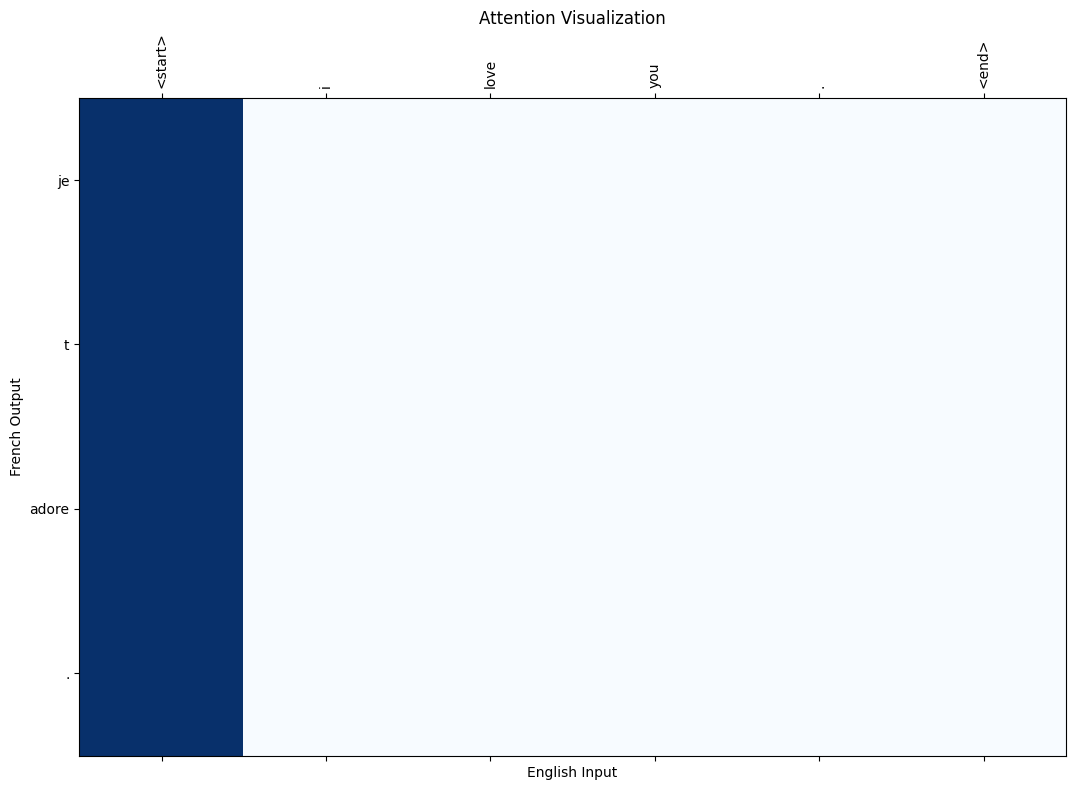


Input: How are you?
Prediction: comment allez vous ? <end>


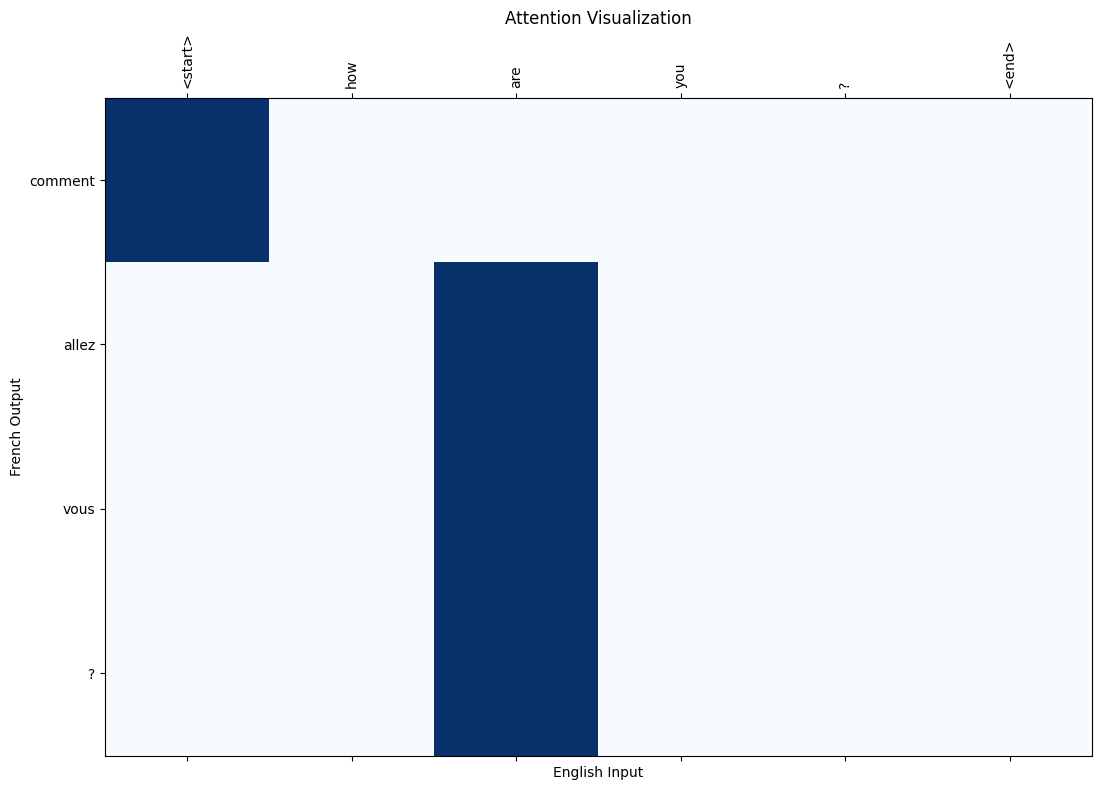


Input: Good morning.
Prediction: bonjour ! <end>


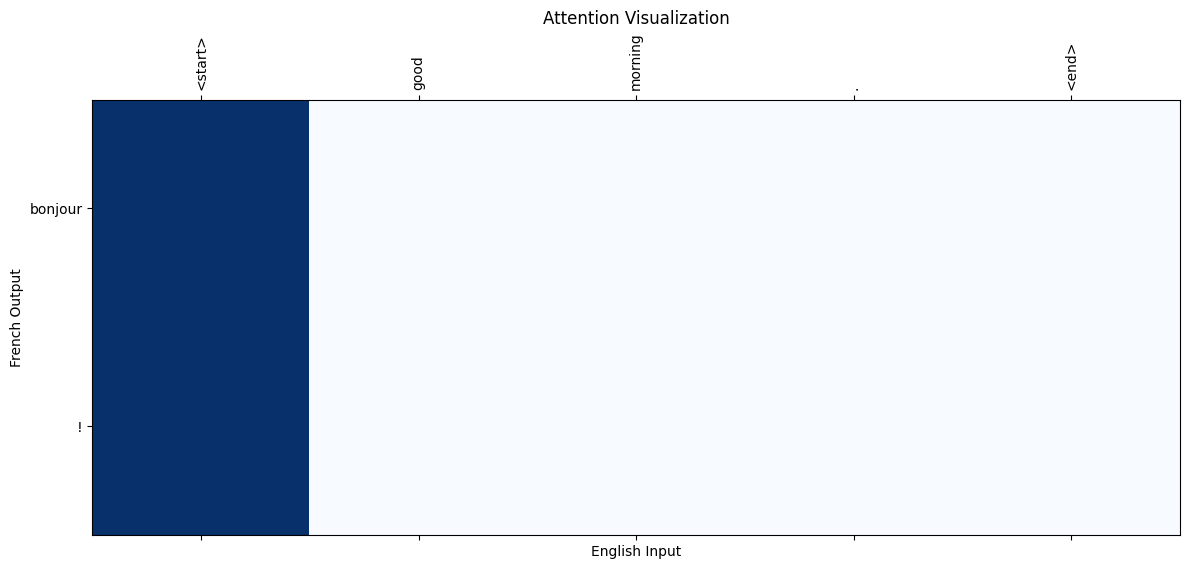


Input: This is a beautiful day.
Prediction: c est une journee . <end>


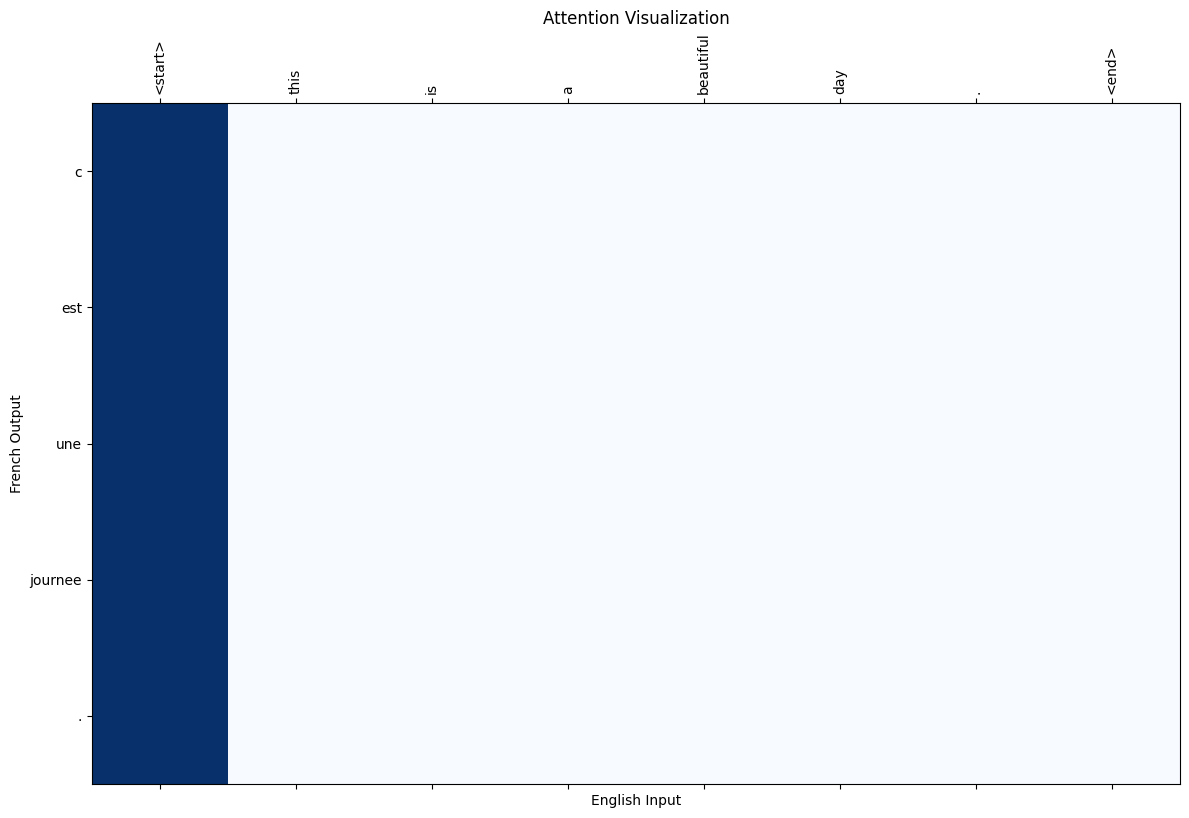


Input: Where is the bathroom?
Prediction: ou est la ? <end>


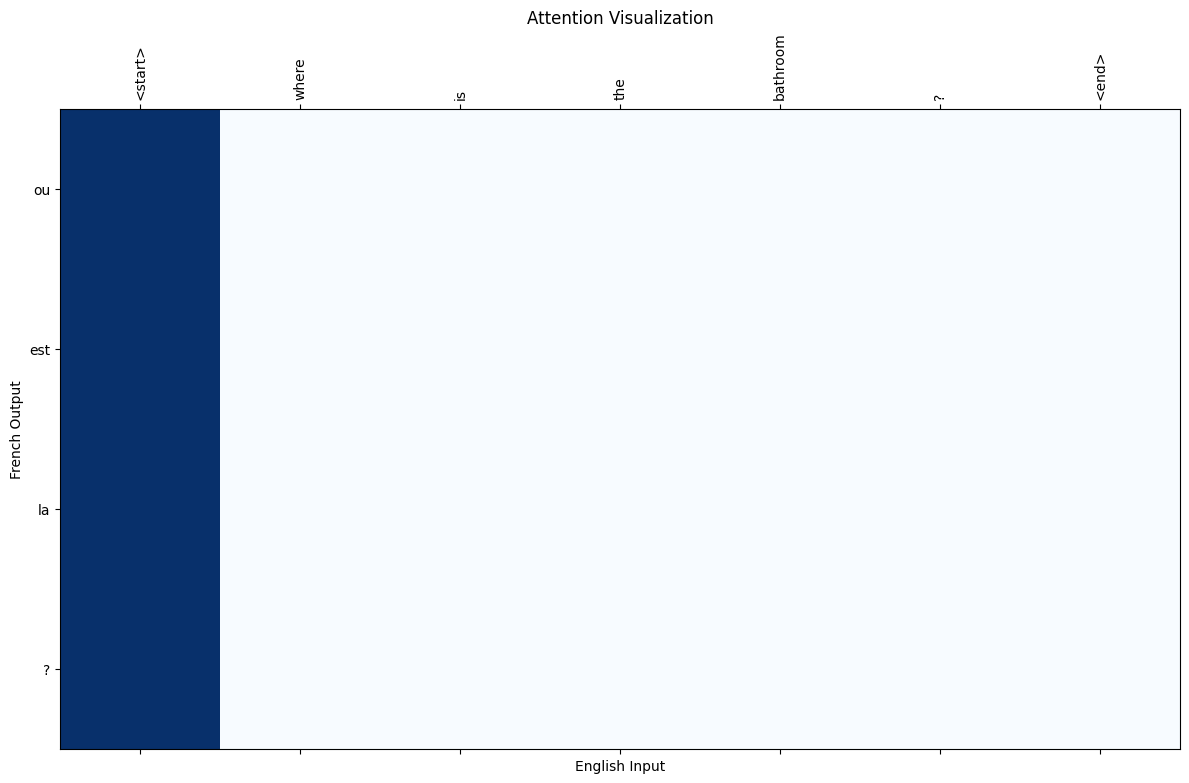



EVALUATING ON VALIDATION SET
English: <start> he is not japanese . <end>
Reference: il n est pas japonais .
Predicted: ne meurs pas !
BLEU Score: 0.00
--------------------------------------------------
English: <start> that s normal . <end>
Reference: c est normal .
Predicted: tenez !
BLEU Score: 0.00
--------------------------------------------------
English: <start> beat it . <end>
Reference: pars d ici .
Predicted: commencez a faire .
BLEU Score: 0.00
--------------------------------------------------
English: <start> it s an ambush ! <end>
Reference: un guet apens !
Predicted: c est ton probleme !
BLEU Score: 0.00
--------------------------------------------------
English: <start> you were fantastic . <end>
Reference: vous etiez fantastique .
Predicted: on etait frais .
BLEU Score: 0.00
--------------------------------------------------
Average BLEU Score: 3.62


In [23]:
def main():
    # Hyperparameters - OPTIMIZED
    BATCH_SIZE = 128
    embedding_dim = 384
    units = 768
    EPOCHS = 40  # Reduced from 30

    print("Loading and preprocessing data...")

    # Load dataset (replace with your dataset path)
    en, fr = create_dataset('fra.txt', num_examples=50000)  # Reduced from 60K

    # Create tokenizers and datasets
    input_tensor, target_tensor, en_tokenizer, fr_tokenizer, max_length_en, max_length_fr = create_tokenizers_and_datasets(en, fr)

    # Split dataset
    input_tensor_train, input_tensor_val, target_tensor_train, target_tensor_val = train_test_split(
        input_tensor, target_tensor, test_size=0.2, random_state=42)

    print(f"Training samples: {len(input_tensor_train)}")
    print(f"Validation samples: {len(input_tensor_val)}")

    # Create tf.data.Dataset
    BUFFER_SIZE = len(input_tensor_train)
    steps_per_epoch = len(input_tensor_train) // BATCH_SIZE

    dataset = tf.data.Dataset.from_tensor_slices((input_tensor_train, target_tensor_train))
    dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)

    # Initialize model
    model = EncoderDecoderModel(
        enc_vocab_size=len(en_tokenizer.word2idx),
        dec_vocab_size=len(fr_tokenizer.word2idx),
        embedding_dim=embedding_dim,
        enc_units=units,
        dec_units=units,
        batch_size=BATCH_SIZE
    )

    # Build the model by doing a dummy forward pass
    sample_batch = next(iter(dataset))
    _ = model([sample_batch[0], sample_batch[1][:, :-1]], training=False)
    print("Model built successfully!")

    # Initialize optimizer AFTER model is built
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

    print("Starting training...")
    # Train model
    train_model(model, dataset, EPOCHS, steps_per_epoch, optimizer)  # FIXED: Added optimizer

    # Save final model
    os.makedirs('checkpoints', exist_ok=True)
    model.save_weights('checkpoints/final_model.weights.h5')
    print("Training completed and model saved!")

    # Test translation
    test_sentences = [
        "I love you.",
        "How are you?",
        "Good morning.",
        "This is a beautiful day.",
        "Where is the bathroom?"
    ]

    print("\n" + "="*50)
    print("TESTING TRANSLATIONS")
    print("="*50)

    for sentence in test_sentences:
        visualize_attention_for_sentence(sentence, model, en_tokenizer, fr_tokenizer, max_length_fr)
        print()

    # Evaluate on validation set
    print("\n" + "="*50)
    print("EVALUATING ON VALIDATION SET")
    print("="*50)

    # Convert validation tensors back to sentences for BLEU evaluation
    val_en_sentences = [en_tokenizer.decode(seq) for seq in input_tensor_val[:100]]
    val_fr_sentences = [fr_tokenizer.decode(seq) for seq in target_tensor_val[:100]]

    avg_bleu = evaluate_model(model, val_en_sentences, val_fr_sentences,
                            en_tokenizer, fr_tokenizer, max_length_fr)

if __name__ == "__main__":
    main()

**Usage Example for Prediction**

In [ ]:
# Load trained model for inference
def load_and_translate():
    # Assuming you have saved tokenizers and model parameters
    # You would need to implement save/load functions for tokenizers

    # Initialize model with same parameters
    model = EncoderDecoderModel(
        enc_vocab_size=len(en_tokenizer.word2idx),
        dec_vocab_size=len(fr_tokenizer.word2idx),
        embedding_dim=256,
        enc_units=512,
        dec_units=512,
        batch_size=1  # For inference, batch size can be 1
    )

    # Load weights
    model.load_weights('checkpoints/final_model')

    # Translate new sentences
    sentences_to_translate = [
        "Hello, how are you today?",
        "I would like to order coffee.",
        "What time is it?",
        "Thank you very much.",
        "See you tomorrow."
    ]

    for sentence in sentences_to_translate:
        translation, attention = evaluate_translation(
            sentence, model, en_tokenizer, fr_tokenizer, max_length_fr)

        print(f"English: {sentence}")
        print(f"French: {translation}")
        print("-" * 40)